# 04 · Gradient Descent ve Optimizerlar
**Calculus Lab**

---
> **Bu notebook'ta ne öğreneceğiz?**  
> 03'te bir sinir ağının gradyanını (backprop ile) NASIL bulacağımızı öğrendik. Ama
> gradyanı bulmak sadece yarı iş — bulduğun gradyanla parametreleri NASIL güncelleyeceğin
> de ayrı bir soru. Bu notebook, tam olarak o soruya cevap veriyor: **gradient descent**
> ve onun modern varyantları (SGD, Momentum, Adam). Bunlar, her `model.fit()` veya
> `optimizer.step()` çağrısının arkasında GERÇEKTEN ne olduğunu gösteriyor.

**Önkoşul:** Türev/Gradyan (01), Jacobian/Hessian/Konvekslik (02), Zincir Kuralı/Backprop (03)  
**Veri:**  
- `ENB2012_data.xlsx` — 768 bina, UCI Energy Efficiency (ısıtma/soğutma yükü tahmini)  
- Sentetik yüzeyler (Rosenbrock fonksiyonu) — optimizer karşılaştırması için  
**Araçlar:** Python (`numpy`, `matplotlib`)

---
## 1 · Gradient Descent: 01'deki Gradyanı "Kullanmaya" Başlıyoruz

01'de gradyanın "en dik ARTIŞ yönünü" gösterdiğini öğrenmiştik. Bir loss fonksiyonunu
**minimize** etmek istiyorsak, gradyanın TAM TERSİ yönünde ilerlememiz gerekiyor —
"en dik İNİŞ" yönü:

$$\theta_{\text{yeni}} = \theta_{\text{eski}} - \alpha \nabla f(\theta_{\text{eski}})$$

Burada $\theta$ modelin parametreleri (ağırlıklar), $\alpha$ **öğrenme oranı** (learning
rate — her adımda ne kadar büyük bir adım atacağımız). Bu formülü tekrar tekrar
uyguluyorsun — her adımda parametreler biraz daha loss'un düşük olduğu bir bölgeye
kayıyor, ta ki (umarız) bir minimuma ulaşana kadar.

---
## 2 · Öğrenme Oranının (α) Kritik Rolü

$\alpha$'nın seçimi, gradient descent'in başarısını belirleyen EN önemli faktör:

- **$\alpha$ çok KÜÇÜKSE:** Her adım minik bir kıpırdanma — minimuma ulaşmak SONSUZ
  zaman alabilir (yavaş yakınsama).
- **$\alpha$ çok BÜYÜKSE:** Her adım o kadar büyük ki minimumun ÜZERİNDEN atlıyorsun,
  sonra tekrar atlıyorsun — sonuç ıraksama (diverjans), loss küçülmek yerine BÜYÜYOR.
- **$\alpha$ "doğru" büyüklükteyse:** Düzgün, hızlı bir şekilde minimuma yakınsıyorsun.

Bu, Python 2'de görsel olarak somutlaştıracağımız en pratik ders — gerçek bir model
eğitirken karşılaşacağın ilk ayar (hyperparameter) genelde bu.

---
## 3 · Batch vs Stochastic Gradient Descent

Klasik ("Batch") gradient descent, HER adımda gradyanı TÜM veri setinden hesaplıyor —
büyük veri setlerinde bu çok YAVAŞ olabilir (milyonlarca satırı her adımda taramak gibi).

**Stochastic Gradient Descent (SGD)**, her adımda gradyanı sadece KÜÇÜK bir alt-örneklemden
(hatta bazen tek bir gözlemden) hesaplıyor. Bu, her adımı çok daha HIZLI yapıyor ama
gradyan artık "gürültülü" (tam doğru değil, yaklaşık) — yörünge düzgün bir çizgi yerine
"titrek" bir yol izliyor. Pratikte, büyük veri setlerinde SGD (veya mini-batch SGD —
ikisinin ortası) neredeyse her zaman tercih ediliyor.

---
## 4 · Momentum: "Hız" Kavramını Eklemek

Vanilla gradient descent'in bir sorunu var: dar, eğri "vadilerde" (Python 5'te göreceğiz)
çok yavaş ilerliyor veya salınım yapıyor. **Momentum**, fiziksel bir topun yuvarlanması
benzetmesini matematiğe döküyor — önceki adımların "hızını" biriktiriyorsun:

$$v_{\text{yeni}} = \beta v_{\text{eski}} - \alpha \nabla f(\theta) \qquad \theta_{\text{yeni}} = \theta_{\text{eski}} + v_{\text{yeni}}$$

$\beta$ (genelde $0.9$ civarı), "önceki hızın ne kadarının korunacağını" belirliyor. Bu,
gradyan sürekli AYNI yönde işaret ediyorsa hızlanmayı sağlıyor (bir tepeden aşağı
yuvarlanan top gibi), gradyan yön değiştiriyorsa (salınım) ise hareketi "yumuşatıyor".

---
## 5 · Adam: Momentum + Adaptif Öğrenme Oranı

**Adam (Adaptive Moment Estimation)**, günümüzde en yaygın kullanılan optimizer —
Momentum'un fikrini ($m$ — birinci moment, gradyanın "ortalaması") bir de gradyanın
BÜYÜKLÜĞÜNÜN karesini takip eden ikinci bir terimle ($v$ — ikinci moment) birleştiriyor:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\nabla f(\theta) \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)[\nabla f(\theta)]^2$$
$$\theta_{\text{yeni}} = \theta_{\text{eski}} - \alpha \frac{m_t}{\sqrt{v_t}+\epsilon}$$

**Sezgisi:** $v_t$ büyükse (o parametrenin gradyanı genelde büyük/dalgalı), etkin
öğrenme oranı ($\alpha/\sqrt{v_t}$) OTOMATİK olarak küçülüyor — her parametre kendi
"kişisel" öğrenme oranına sahip oluyormuş gibi davranıyor. Bu, Adam'ın farklı ölçekteki
parametrelerde (bazı ağırlıklar büyük gradyanlı, bazıları küçük) neden bu kadar iyi
çalıştığının sebebi.

---
## 6 · Özet Tablo

| Optimizer | Formül Fikri | Avantajı | Ne Zaman Tercih Edilir |
|---|---|---|---|
| (Batch) Gradient Descent | $\theta-\alpha\nabla f$ | Basit, kararlı | Küçük veri setleri |
| SGD | Aynı, ama küçük alt-örneklemle | Hızlı, büyük veriye ölçeklenir | Büyük veri setleri |
| Momentum | + önceki "hız" | Dar vadilerde hızlanma, salınımı azaltma | Zorlu/eğri loss yüzeyleri |
| Adam | + adaptif öğrenme oranı | Farklı parametrelere farklı hız | Modern derin öğrenmenin varsayılanı |

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **Gradient Descent'i Sıfırdan Kodlama** — Basit bir "vadi" üzerinde yörünge görselleştirmesi
2. **Öğrenme Oranının Etkisi** — Çok küçük / uygun / çok büyük karşılaştırması
3. **Gerçek Veride SGD vs Batch GD** — Energy Efficiency verisiyle
4. **Momentum'un Gücü: Zorlu Bir Vadide** — Rosenbrock fonksiyonu
5. **Adam vs SGD vs Momentum: Final Karşılaştırma**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 7)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🏔️ Python 1 — Gradient Descent'i Sıfırdan Kodlama

**Ne yapıyoruz?**  
$f(x,y)=x^2+2y^2$ (02'deki konveks "çanak" örneğine benzer, ama bu sefer eksenlerde
FARKLI eğrilik var — $y$ yönünde daha "dik") üzerinde gradient descent'i adım adım
çalıştırıp, her adımı yüzey üzerinde bir nokta olarak çizeceğiz.

Başlangıç noktası: [4. 3.], f=34.000
Son nokta (25 adım sonra): [0. 0.], f=0.000000
(Gerçek minimum (0,0)'da, f=0)


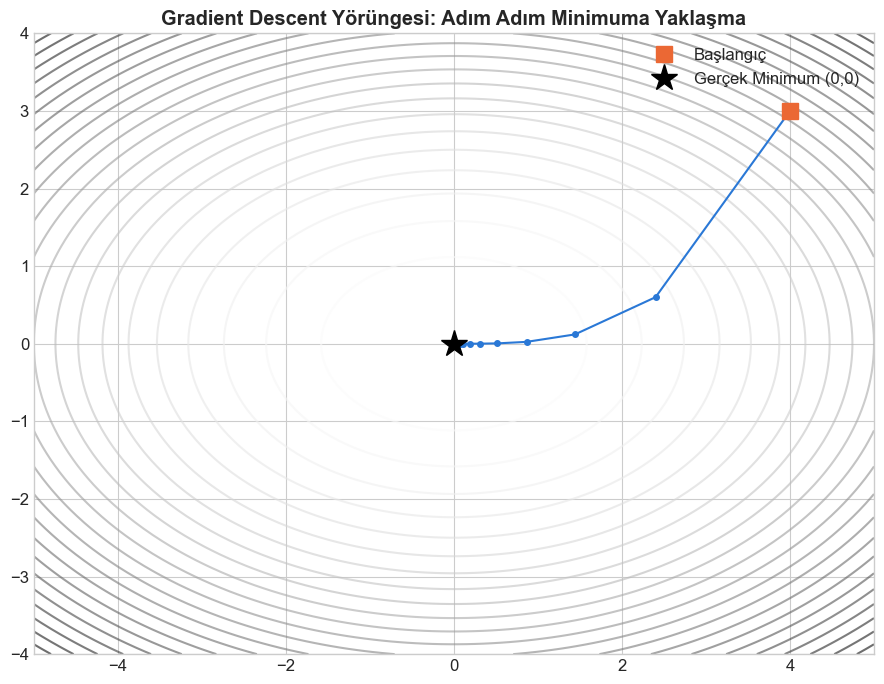


YORUM: Yörünge, gerçek minimuma doğru düzgün bir şekilde yaklaşıyor. Konturların
y-yönünde daha SIK olduğuna dikkat et (yüzey o yönde daha DİK) - bu yüzden yörünge
y-yönünde daha hızlı, x-yönünde daha yavaş ilerliyor (adımların şeklini karşılaştır).


In [24]:
def f_vadi(x, y):
    return x**2 + 2*y**2

def gradyan_vadi(x, y):
    return np.array([2*x, 4*y])  # df/dx=2x, df/dy=4y

def gradient_descent(baslangic, ogrenme_orani, adim_sayisi):
    yol = [baslangic.copy()]
    nokta = baslangic.copy()
    for _ in range(adim_sayisi):
        grad = gradyan_vadi(*nokta)
        nokta = nokta - ogrenme_orani * grad
        yol.append(nokta.copy())
    return np.array(yol)

baslangic = np.array([4.0, 3.0])
yol = gradient_descent(baslangic, ogrenme_orani=0.2, adim_sayisi=25)

print(f"Başlangıç noktası: {baslangic}, f={f_vadi(*baslangic):.3f}")
print(f"Son nokta (25 adım sonra): {np.round(yol[-1], 4)}, f={f_vadi(*yol[-1]):.6f}")
print("(Gerçek minimum (0,0)'da, f=0)")

x_grid = np.linspace(-5, 5, 100)
y_grid = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f_vadi(X, Y)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contour(X, Y, Z, levels=25, cmap='Greys', alpha=0.6)
ax.plot(yol[:, 0], yol[:, 1], 'o-', color='#2a78d6', markersize=4, linewidth=1.5)
ax.plot(*baslangic, 's', color='#eb6834', markersize=12, label='Başlangıç')
ax.plot(0, 0, 'k*', markersize=20, label='Gerçek Minimum (0,0)')
ax.set_title('Gradient Descent Yörüngesi: Adım Adım Minimuma Yaklaşma', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Yörünge, gerçek minimuma doğru düzgün bir şekilde yaklaşıyor. Konturların")
print("y-yönünde daha SIK olduğuna dikkat et (yüzey o yönde daha DİK) - bu yüzden yörünge")
print("y-yönünde daha hızlı, x-yönünde daha yavaş ilerliyor (adımların şeklini karşılaştır).")

---
### ⚡ Python 2 — Öğrenme Oranının Etkisi: Çok Küçük / Uygun / Çok Büyük

**Ne yapıyoruz?**  
Bölüm 2'deki üç senaryoyu AYNI başlangıç noktasından, AYNI fonksiyon üzerinde, SADECE
$\alpha$'yı değiştirerek görsel olarak kanıtlıyoruz.

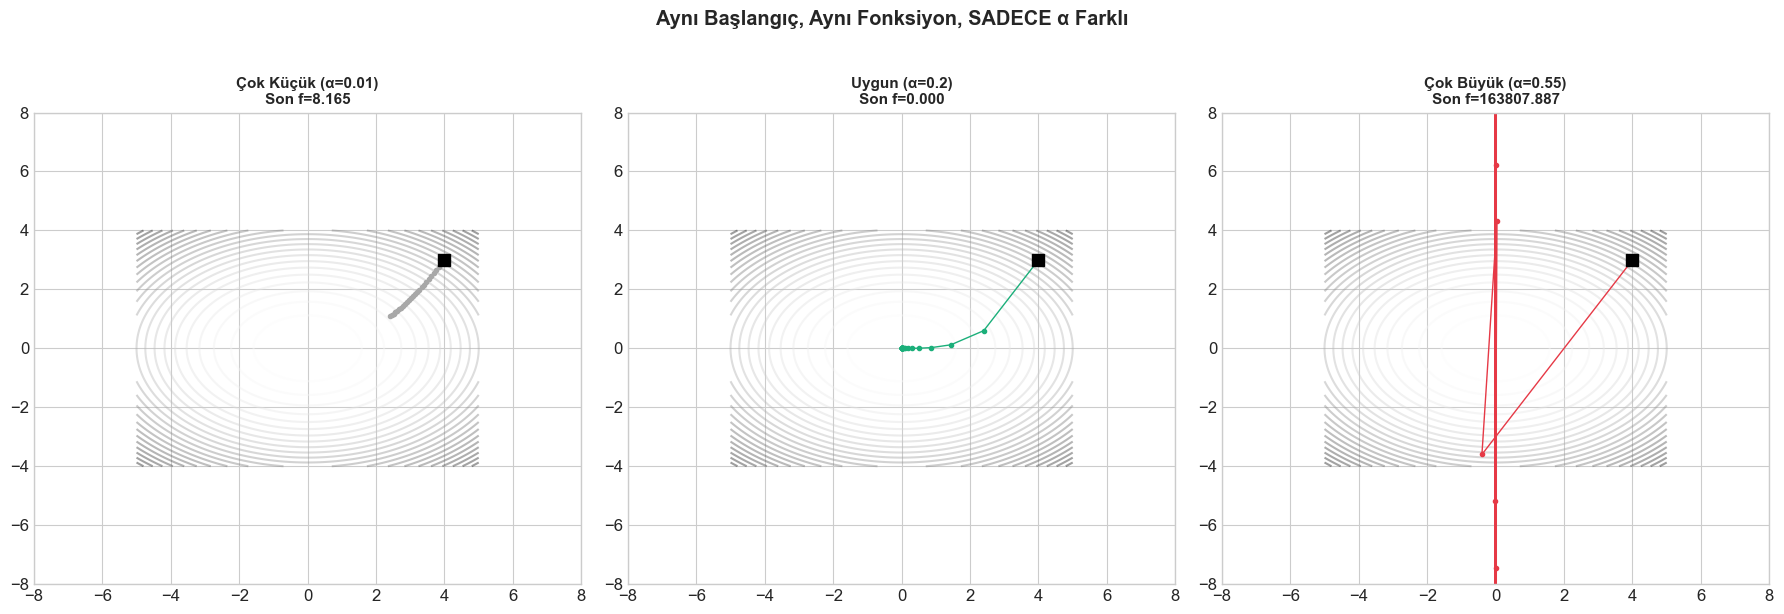

YORUM: Sol grafikte 25 adım sonra hala minimuma UZAK (çok yavaş). Orta grafikte
düzgünce minimuma varmış. Sağ grafikte yörünge minimumun ETRAFINDA sıçrayıp
ıraksıyor (f değeri KÜÇÜLECEĞİNE büyüyor) - α'nın çok büyük olmasının somut sonucu.


In [25]:
ogrenme_oranlari = {'Çok Küçük (α=0.01)': 0.01, 'Uygun (α=0.2)': 0.2, 'Çok Büyük (α=0.55)': 0.55}
renkler = ['#a8a8a8', '#1baf7a', '#e63946']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (isim, alpha), renk in zip(axes, ogrenme_oranlari.items(), renkler):
    yol_test = gradient_descent(baslangic, ogrenme_orani=alpha, adim_sayisi=25)
    ax.contour(X, Y, Z, levels=25, cmap='Greys', alpha=0.4)
    ax.plot(yol_test[:, 0], yol_test[:, 1], 'o-', color=renk, markersize=3, linewidth=1)
    ax.plot(*baslangic, 's', color='black', markersize=8)
    ax.set_title(f'{isim}\nSon f={f_vadi(*yol_test[-1]):.3f}', fontweight='bold', fontsize=11)
    ax.set_xlim(-8, 8); ax.set_ylim(-8, 8)

plt.suptitle('Aynı Başlangıç, Aynı Fonksiyon, SADECE α Farklı', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("YORUM: Sol grafikte 25 adım sonra hala minimuma UZAK (çok yavaş). Orta grafikte")
print("düzgünce minimuma varmış. Sağ grafikte yörünge minimumun ETRAFINDA sıçrayıp")
print("ıraksıyor (f değeri KÜÇÜLECEĞİNE büyüyor) - α'nın çok büyük olmasının somut sonucu.")

---
### 🏠 Python 3 — Gerçek Veride Batch GD vs SGD (Mini-Batch)

**Ne yapıyoruz?**  
Energy Efficiency verisinde (bina özelliklerinden ısıtma yükü tahmini) bir lineer
regresyon kuruyoruz — bir kere TÜM veriyle (Batch GD), bir kere küçük gruplar halinde
(mini-batch SGD) eğitip loss eğrilerini karşılaştırıyoruz.

Veri: 768 bina, 10 sütun
X1-X8: bina özellikleri (kompaktlık, yüzey alanı, duvar/çatı alanı, yükseklik, vb.)
Y1: Isıtma Yükü (tahmin edeceğimiz hedef)

Batch GD  - ilk loss: 348.207, son loss: 8.775
Mini-batch SGD - ilk loss: 10.781, son loss: 8.665


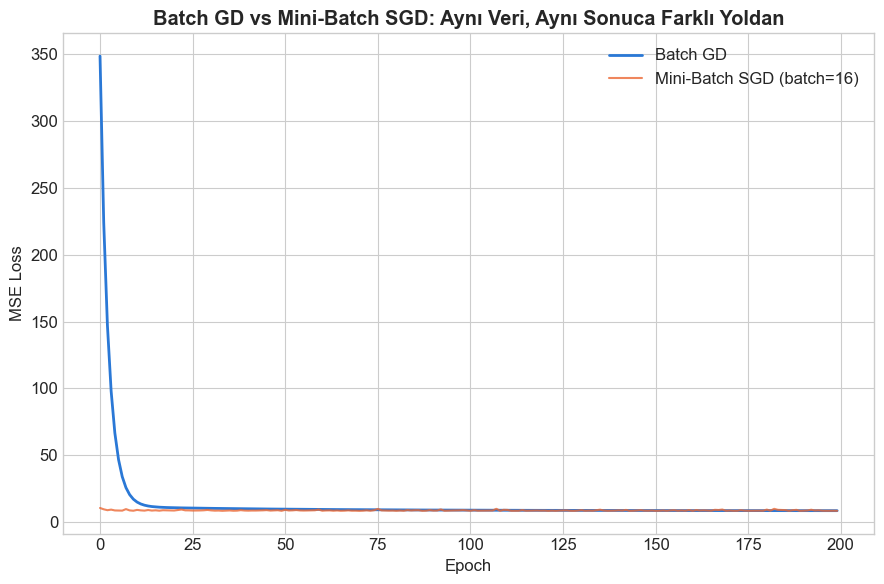


YORUM: İkisi de benzer bir son loss'a ulaşıyor - ama SGD, her EPOCH'ta 768/16=48
kez güncelleme yaparken Batch GD sadece 1 kez güncelleme yapıyor. Bu, SGD'nin
NEDEN büyük veri setlerinde (milyonlarca satır) tercih edildiğinin sebebi -
her epoch'ta çok daha fazla 'öğrenme fırsatı' sağlıyor.


In [4]:
enerji = pd.read_excel('data/ENB2012_data.xlsx')
print(f"Veri: {enerji.shape[0]} bina, {enerji.shape[1]} sütun")
print("X1-X8: bina özellikleri (kompaktlık, yüzey alanı, duvar/çatı alanı, yükseklik, vb.)")
print("Y1: Isıtma Yükü (tahmin edeceğimiz hedef)")

X = enerji[['X1', 'X2', 'X3', 'X4', 'X5', 'X7']].values
y = enerji['Y1'].values.reshape(-1, 1)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)  # standartlaştır
n, d = X_std.shape
X_ext = np.column_stack([np.ones(n), X_std])  # intercept sütunu

def mse_loss(beta, X, y):
    return np.mean((X @ beta - y) ** 2)

def gradyan_mse(beta, X, y):
    return (2 / len(y)) * X.T @ (X @ beta - y)

rng = np.random.default_rng(42)
beta_baslangic = rng.normal(0, 0.1, (d + 1, 1)) # Başlangıç ağırlıkları (intercept dahil)
alpha = 0.1 # Ögrenme oranı (learning rate)
n_epoch = 200 # Kaç kez tüm veri üzerinden geçilecek (batch GD için) veya kaç kez mini-batch SGD yapılacak

# ===== BATCH GD: HER adimda TUM veriyi kullan =====
beta_batch = beta_baslangic.copy()
loss_batch = []
for epoch in range(n_epoch):
    grad = gradyan_mse(beta_batch, X_ext, y)
    beta_batch = beta_batch - alpha * grad
    loss_batch.append(mse_loss(beta_batch, X_ext, y))

# ===== MINI-BATCH SGD: HER adimda sadece 16 satirlik bir alt-orneklem kullan =====
beta_sgd = beta_baslangic.copy()
batch_boyutu = 16
loss_sgd = []
rng2 = np.random.default_rng(0)
for epoch in range(n_epoch):
    karisik_index = rng2.permutation(n)
    for i in range(0, n, batch_boyutu):
        alt_ornek_idx = karisik_index[i:i + batch_boyutu]
        X_batch, y_batch = X_ext[alt_ornek_idx], y[alt_ornek_idx]
        grad = gradyan_mse(beta_sgd, X_batch, y_batch)
        beta_sgd = beta_sgd - alpha * grad
    loss_sgd.append(mse_loss(beta_sgd, X_ext, y))  # TUM veri uzerinde loss'u olc (karsilastirma icin)

print(f"\nBatch GD  - ilk loss: {loss_batch[0]:.3f}, son loss: {loss_batch[-1]:.3f}")
print(f"Mini-batch SGD - ilk loss: {loss_sgd[0]:.3f}, son loss: {loss_sgd[-1]:.3f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(loss_batch, color='#2a78d6', linewidth=2, label='Batch GD')
ax.plot(loss_sgd, color='#eb6834', linewidth=1.5, alpha=0.8, label='Mini-Batch SGD (batch=16)')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Batch GD vs Mini-Batch SGD: Aynı Veri, Aynı Sonuca Farklı Yoldan', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: İkisi de benzer bir son loss'a ulaşıyor - ama SGD, her EPOCH'ta 768/16=48")
print("kez güncelleme yaparken Batch GD sadece 1 kez güncelleme yapıyor. Bu, SGD'nin")
print("NEDEN büyük veri setlerinde (milyonlarca satır) tercih edildiğinin sebebi -")
print("her epoch'ta çok daha fazla 'öğrenme fırsatı' sağlıyor.")

---
### 🏁 Python 4 — Momentum'un Gücü: Rosenbrock Fonksiyonu

**Ne yapıyoruz?**  
**Rosenbrock fonksiyonu** ($f(x,y)=(1-x)^2+100(y-x^2)^2$), optimizasyon algoritmalarını
test etmek için kullanılan klasik bir "zorlu yüzey" — dar, eğri bir "vadi" şeklinde
(muz şeklinde de anılır). Vanilla gradient descent bu vadide çok YAVAŞ ilerliyor (vadinin
duvarları arasında salınarak); Momentum'un bunu nasıl hızlandırdığını göreceğiz.

Gerçek minimum: (1, 1), f=0
Vanilla GD  (3000 adım sonra): [0.7796 0.6068], f=0.048669
Momentum    (3000 adım sonra): [1. 1.], f=0.0000000000


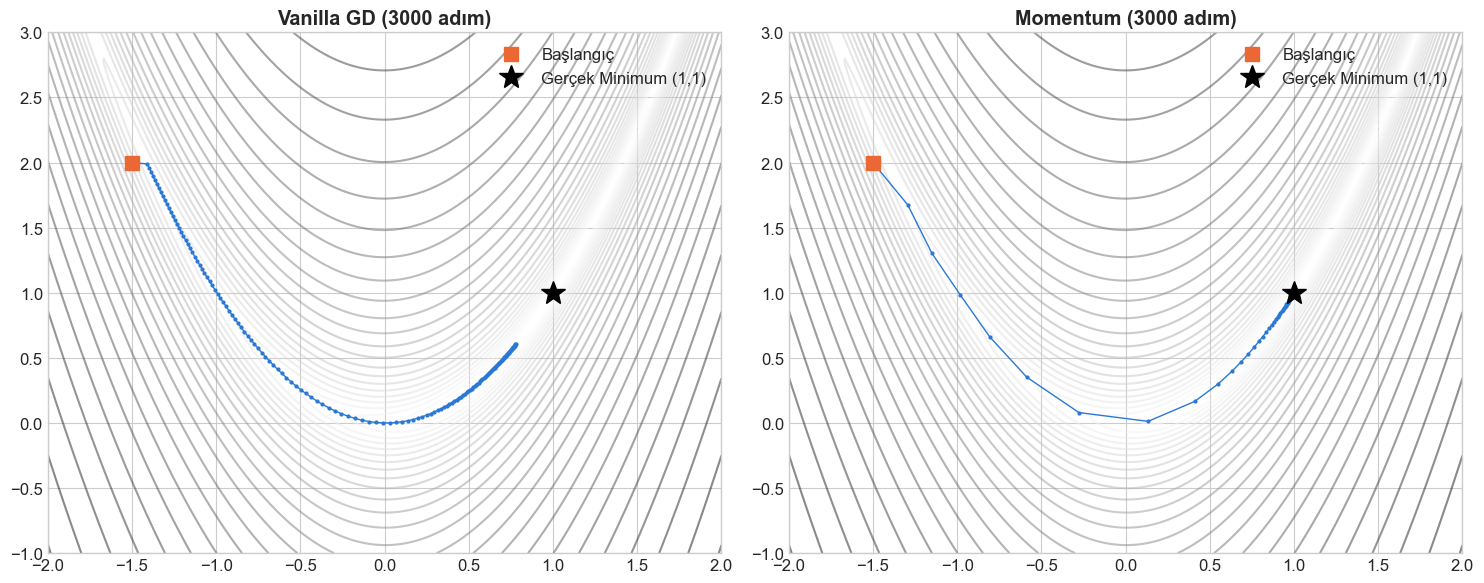


YORUM: Vanilla GD, aynı adım sayısında hala minimuma epey uzak - vadinin dar
duvarları arasında ADIM ADIM ilerlemek zorunda kalıyor. Momentum ise 'biriken hız'
sayesinde vadi boyunca çok daha HIZLI akıyor ve neredeyse TAM minimuma ulaşıyor -
bu, Momentum'un gerçek derin öğrenmede NEDEN vazgeçilmez olduğunun klasik kanıtı.


In [5]:
def rosenbrock(x, y, a=1, b=100):
    return (a - x)**2 + b * (y - x**2)**2

def gradyan_rosenbrock(x, y, a=1, b=100):
    dx = -2*(a - x) - 4*b*x*(y - x**2)
    dy = 2*b*(y - x**2)
    return np.array([dx, dy])

def vanilla_gd(baslangic, alpha, n_adim):
    yol = [baslangic.copy()]
    nokta = baslangic.copy()
    for _ in range(n_adim):
        grad = gradyan_rosenbrock(*nokta)
        nokta = nokta - alpha * grad
        yol.append(nokta.copy())
    return np.array(yol)

def momentum_gd(baslangic, alpha, beta, n_adim):
    yol = [baslangic.copy()]
    nokta = baslangic.copy()
    v = np.zeros(2)
    for _ in range(n_adim):
        grad = gradyan_rosenbrock(*nokta)
        v = beta * v - alpha * grad          # Bölüm 4'teki Momentum formülü
        nokta = nokta + v
        yol.append(nokta.copy())
    return np.array(yol)

baslangic_r = np.array([-1.5, 2.0])
alpha_r = 0.001  # Rosenbrock cok dik oldugu icin kucuk bir alpha gerekiyor
n_adim_r = 3000

yol_vanilla = vanilla_gd(baslangic_r, alpha_r, n_adim_r)
yol_momentum = momentum_gd(baslangic_r, alpha_r, 0.9, n_adim_r)

print(f"Gerçek minimum: (1, 1), f=0")
print(f"Vanilla GD  ({n_adim_r} adım sonra): {np.round(yol_vanilla[-1], 4)}, f={rosenbrock(*yol_vanilla[-1]):.6f}")
print(f"Momentum    ({n_adim_r} adım sonra): {np.round(yol_momentum[-1], 4)}, f={rosenbrock(*yol_momentum[-1]):.10f}")

x_r = np.linspace(-2, 2, 300)
y_r = np.linspace(-1, 3, 300)
X_r, Y_r = np.meshgrid(x_r, y_r)
Z_r = rosenbrock(X_r, Y_r)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, yol, baslik in zip(axes, [yol_vanilla, yol_momentum], ['Vanilla GD', 'Momentum']):
    ax.contour(X_r, Y_r, np.log(Z_r + 1), levels=30, cmap='Greys', alpha=0.5)  # log olcek, vadiyi daha net gostermek icin
    ax.plot(yol[::20, 0], yol[::20, 1], 'o-', color='#2a78d6', markersize=2, linewidth=1)
    ax.plot(*baslangic_r, 's', color='#eb6834', markersize=10, label='Başlangıç')
    ax.plot(1, 1, 'k*', markersize=18, label='Gerçek Minimum (1,1)')
    ax.set_title(f'{baslik} ({n_adim_r} adım)', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

print("\nYORUM: Vanilla GD, aynı adım sayısında hala minimuma epey uzak - vadinin dar")
print("duvarları arasında ADIM ADIM ilerlemek zorunda kalıyor. Momentum ise 'biriken hız'")
print("sayesinde vadi boyunca çok daha HIZLI akıyor ve neredeyse TAM minimuma ulaşıyor -")
print("bu, Momentum'un gerçek derin öğrenmede NEDEN vazgeçilmez olduğunun klasik kanıtı.")

---
### 🥇 Python 5 — Adam vs SGD vs Momentum: Final Karşılaştırma

**Ne yapıyoruz?**  
Bölüm 5'teki Adam formülünü kodlayıp, AYNI Rosenbrock yüzeyinde, AYNI adım sayısıyla
üçünü (Vanilla GD, Momentum, Adam) yan yana karşılaştırıyoruz — hangisi en hızlı, en
güvenilir şekilde gerçek minimuma ulaşıyor?

Gerçek minimum: (1, 1), f=0

Vanilla GD (3000 adım): [0.7796 0.6068], f=0.048669
Momentum   (3000 adım): [1. 1.], f=0.0000000000
Adam       (3000 adım): [1. 1.], f=0.0000000000


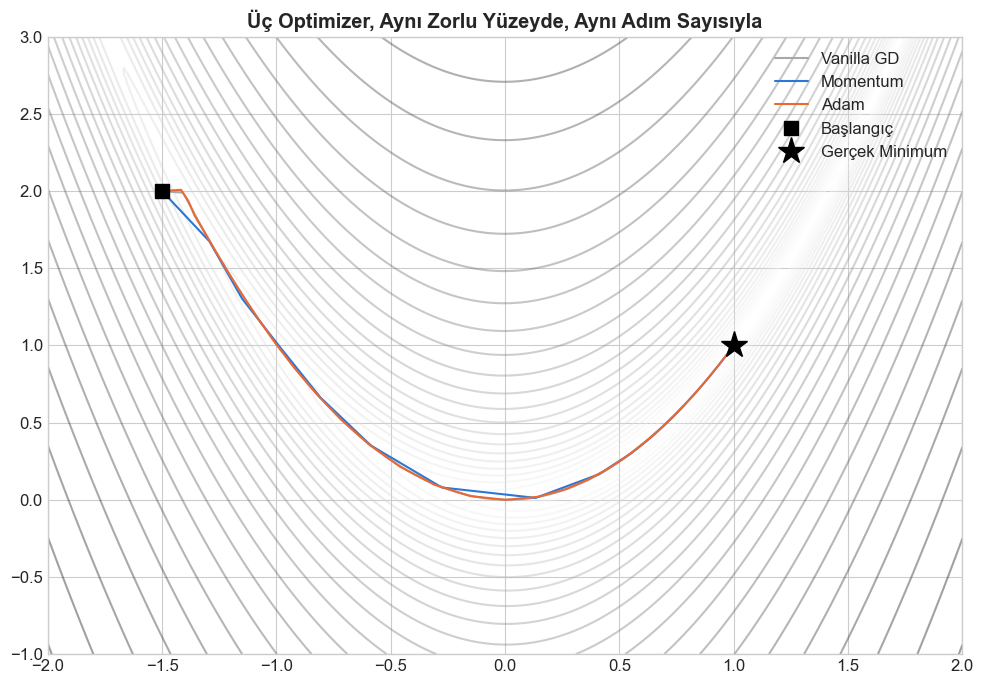


YORUM: Vanilla GD (gri) en yavaş - hala vadinin içinde ilerliyor. Momentum
(mavi) ve Adam (turuncu) ikisi de neredeyse tam minimuma ulaşmış - modern derin
öğrenme kütüphanelerinin (PyTorch, TensorFlow) VARSAYILAN olarak Adam'ı önermesinin
sebebi tam olarak bu: hem hızlı hem farklı problemlerde 'ayar' gerektirmeden güvenilir.


In [ ]:
def adam_gd(baslangic, alpha, beta1, beta2, n_adim, eps=1e-8):
    yol = [baslangic.copy()]
    nokta = baslangic.copy()
    m = np.zeros(2); v = np.zeros(2)  # Bolum 5'teki birinci ve ikinci moment
    for t in range(1, n_adim + 1):
        grad = gradyan_rosenbrock(*nokta)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**t)   # "bias correction" - baslangicta m,v sifira yakin oldugu icin duzeltme
        v_hat = v / (1 - beta2**t)
        nokta = nokta - alpha * m_hat / (np.sqrt(v_hat) + eps)
        yol.append(nokta.copy())
    return np.array(yol)

# Adam genelde daha buyuk bir alpha ile bile stabil calisabilir (adaptif oldugu icin)
yol_adam = adam_gd(baslangic_r, alpha=0.05, beta1=0.9, beta2=0.999, n_adim=n_adim_r)

print(f"Gerçek minimum: (1, 1), f=0\n")
print(f"Vanilla GD ({n_adim_r} adım): {np.round(yol_vanilla[-1], 4)}, f={rosenbrock(*yol_vanilla[-1]):.6f}")
print(f"Momentum   ({n_adim_r} adım): {np.round(yol_momentum[-1], 4)}, f={rosenbrock(*yol_momentum[-1]):.10f}")
print(f"Adam       ({n_adim_r} adım): {np.round(yol_adam[-1], 4)}, f={rosenbrock(*yol_adam[-1]):.10f}")

fig, ax = plt.subplots(figsize=(10, 7))
ax.contour(X_r, Y_r, np.log(Z_r + 1), levels=30, cmap='Greys', alpha=0.4)
ax.plot(yol_vanilla[::20, 0], yol_vanilla[::20, 1], '-', color='#a8a8a8', linewidth=1.5, label='Vanilla GD')
ax.plot(yol_momentum[::20, 0], yol_momentum[::20, 1], '-', color='#2a78d6', linewidth=1.5, label='Momentum')
ax.plot(yol_adam[::20, 0], yol_adam[::20, 1], '-', color='#eb6834', linewidth=1.5, label='Adam')
ax.plot(*baslangic_r, 's', color='black', markersize=10, label='Başlangıç')
ax.plot(1, 1, 'k*', markersize=20, label='Gerçek Minimum')
ax.set_title('Üç Optimizer, Aynı Zorlu Yüzeyde, Aynı Adım Sayısıyla', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Vanilla GD (gri) en yavaş - hala vadinin içinde ilerliyor. Momentum")
print("(mavi) ve Adam (turuncu) ikisi de neredeyse tam minimuma ulaşmış - modern derin")
print("öğrenme kütüphanelerinin (PyTorch, TensorFlow) VARSAYILAN olarak Adam'ı önermesinin")
print("sebebi tam olarak bu: hem hızlı hem farklı problemlerde 'ayar' gerektirmeden güvenilir.")

---
## ✏️ Egzersizler

---

### **E1.** 
Python 1'deki $f(x,y)=x^2+2y^2$ fonksiyonunu $f(x,y)=5x^2+y^2$ ile değiştir
(eksenler arası eğrilik farkını daha da büyüt). Aynı $\alpha=0.2$ ile gradient descent
çalıştır — yörünge nasıl değişiyor, hâlâ düzgün mü yakınsıyor?


 ==== Egzersiz 1: Gradient Descent ====
Başlangıç noktası: [ 6. -5.], f=205.000
Son nokta (25 adım sonra): [-6. -0.], f=180.000000
Gerçek minimumda mı (0,0)'da, f=0? Hayır


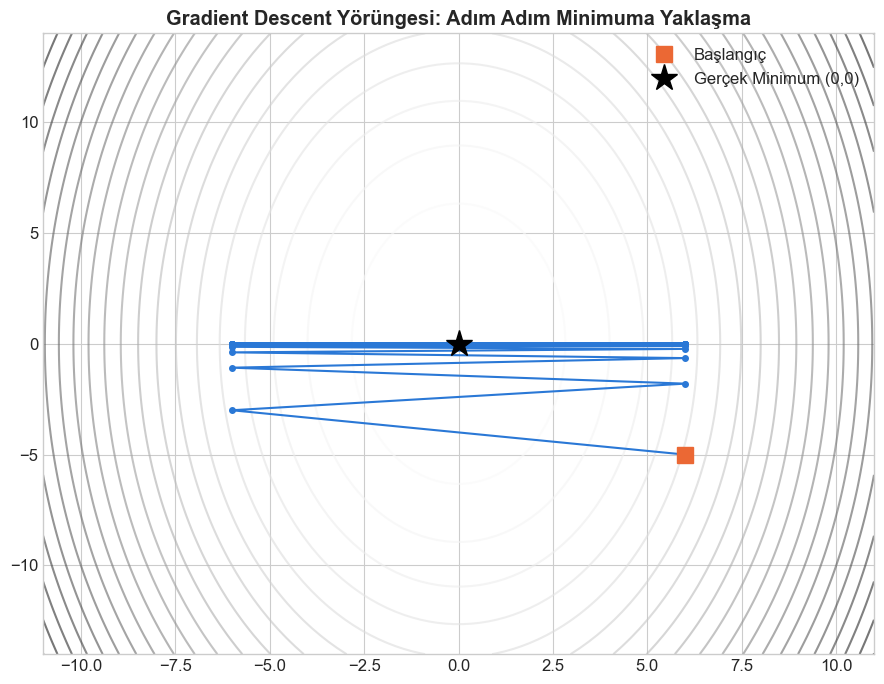


 YORUM: Düzgün şekilde yakınsamadı zigzaglar çizdi x'te çok hızlı yer değiştirirken y'de çok yavaş yer değiştiriyor. Bu yüzden x'te çok hızlı ilerlerken y'de çok yavaş ilerliyor. Bu yüzden zigzaglar çiziyor.


In [27]:
print("\n ==== Egzersiz 1: Gradient Descent ====")

# Vadi'nin fonksiyonu
def f_vadi(x, y):
    return 5*x**2 + y**2
# Vadi'nin gradyanı
def gradyan_vadi(x, y):
    return np.array([10*x, 2*y])  # df/dx=10x, df/dy=2y

# Gradient Descent fonksiyonu
def gradient_descent(baslangic, ogrenme_orani, adim_sayisi):
    yol = [baslangic.copy()]
    nokta = baslangic.copy()
    for _ in range(adim_sayisi):
        grad = gradyan_vadi(*nokta) # Gradyanı hesapla
        nokta = nokta - ogrenme_orani * grad # Gradient Descent adımı
        yol.append(nokta.copy())
    return np.array(yol) 

baslangic = np.array([6.0, -5.0])
yol = gradient_descent(baslangic, ogrenme_orani=0.2, adim_sayisi=25)

print(f"Başlangıç noktası: {baslangic}, f={f_vadi(*baslangic):.3f}")
print(f"Son nokta (25 adım sonra): {np.round(yol[-1], 4)}, f={f_vadi(*yol[-1]):.6f}")
print(f"Gerçek minimumda mı (0,0)'da, f=0? {'Evet' if np.allclose(yol[-1], [0, 0]) else 'Hayır'}")

x_grid = np.linspace(-11, 11, 100)
y_grid = np.linspace(-14, 14, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f_vadi(X, Y)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contour(X, Y, Z, levels=25, cmap='Greys', alpha=0.6)
ax.plot(yol[:, 0], yol[:, 1], 'o-', color='#2a78d6', markersize=4, linewidth=1.5)
ax.plot(*baslangic, 's', color='#eb6834', markersize=12, label='Başlangıç')
ax.plot(0, 0, 'k*', markersize=20, label='Gerçek Minimum (0,0)')
ax.set_title('Gradient Descent Yörüngesi: Adım Adım Minimuma Yaklaşma', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\n YORUM: Düzgün şekilde yakınsamadı zigzaglar çizdi x'te çok hızlı yer değiştirirken y'de çok yavaş yer değiştiriyor. Bu yüzden x'te çok hızlı ilerlerken y'de çok yavaş ilerliyor. Bu yüzden zigzaglar çiziyor.")

---

### **E2.** 
Python 2'deki üç öğrenme oranı senaryosunu, YENİ bir başlangıç noktasından
($[6,-5]$ gibi) tekrarla — "uygun" kabul ettiğimiz $\alpha=0.2$ bu sefer de iyi çalışıyor mu?



 ==== Egzersiz 2: Öğrenme Oranı Farklılıkları ====


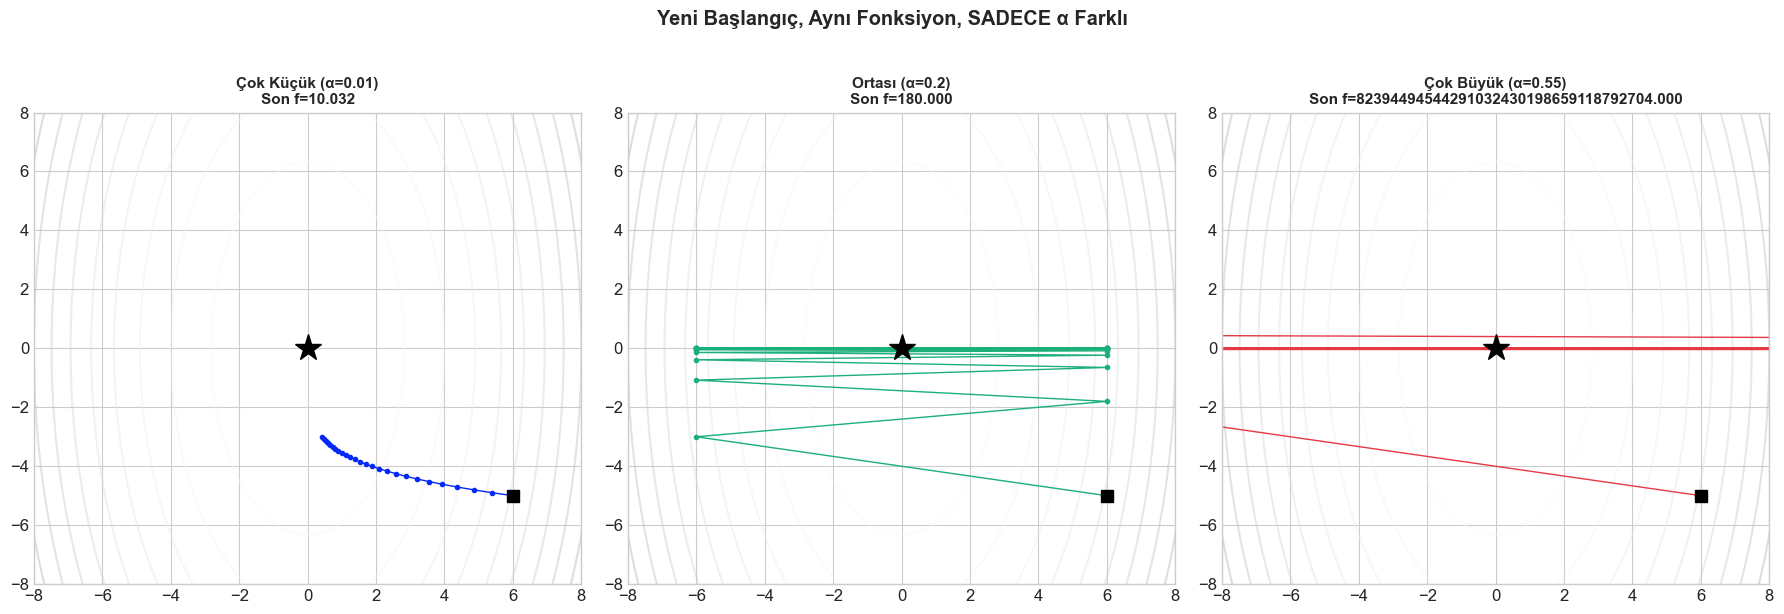

YORUM: Küçüldükçe daha yakınlaşması düzgün oluyor ama büyüdükçe çok fazla zigzaglar çiziyor ve minimuma ulaşamıyor. Bu yüzden öğrenme oranı çok önemli.


In [31]:
print("\n ==== Egzersiz 2: Öğrenme Oranı Farklılıkları ====")
ogrenme_oranlari = {'Çok Küçük (α=0.01)': 0.01, 'Ortası (α=0.2)': 0.2, 'Çok Büyük (α=0.55)': 0.55}
renkler = ["#0429f7", '#1baf7a', '#e63946']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (isim, alpha), renk in zip(axes, ogrenme_oranlari.items(), renkler):
    baslangic = np.array([6.0, -5.0]) # Yeni başlangıç noktası
    yol_test = gradient_descent(baslangic, ogrenme_orani=alpha, adim_sayisi=25)
    ax.contour(X, Y, Z, levels=25, cmap='Greys', alpha=0.4)
    ax.plot(yol_test[:, 0], yol_test[:, 1], 'o-', color=renk, markersize=3, linewidth=1)
    ax.plot(*baslangic, 's', color='black', markersize=8)
    ax.plot(0, 0, 'k*', markersize=20, label='Gerçek Minimum (0,0)')
    ax.set_title(f'{isim}\nSon f={f_vadi(*yol_test[-1]):.3f}', fontweight='bold', fontsize=11)
    ax.set_xlim(-8, 8); ax.set_ylim(-8, 8)

plt.suptitle('Yeni Başlangıç, Aynı Fonksiyon, SADECE α Farklı', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("YORUM: Küçüldükçe daha yakınlaşması düzgün oluyor ama büyüdükçe çok fazla zigzaglar çiziyor ve minimuma ulaşamıyor. Bu yüzden öğrenme oranı çok önemli.")


---

### **E3.** 
Python 3'teki mini-batch SGD kodunda `batch_boyutu`'nu 16 yerine 4 ve 128 aralığında
değiştirerek tekrarla — loss eğrisinin "gürültüsü" (dalgalanma miktarı) nasıl değişiyor?
Bunu Bölüm 3'teki "SGD gürültülü gradyan" açıklamasıyla ilişkilendir.


 ==== Egzersiz 3: Mini-Batch SGD Farklı Batch Boytularına Göre Dalgalanma Miktarı ====
Batch boyutu 4 - ilk loss: 12.400, son loss: 9.163
Batch boyutu 8 - ilk loss: 11.136, son loss: 8.696
Batch boyutu 16 - ilk loss: 10.781, son loss: 8.665
Batch boyutu 32 - ilk loss: 11.109, son loss: 8.637
Batch boyutu 64 - ilk loss: 14.090, son loss: 8.624
Batch boyutu 128 - ilk loss: 46.375, son loss: 8.638


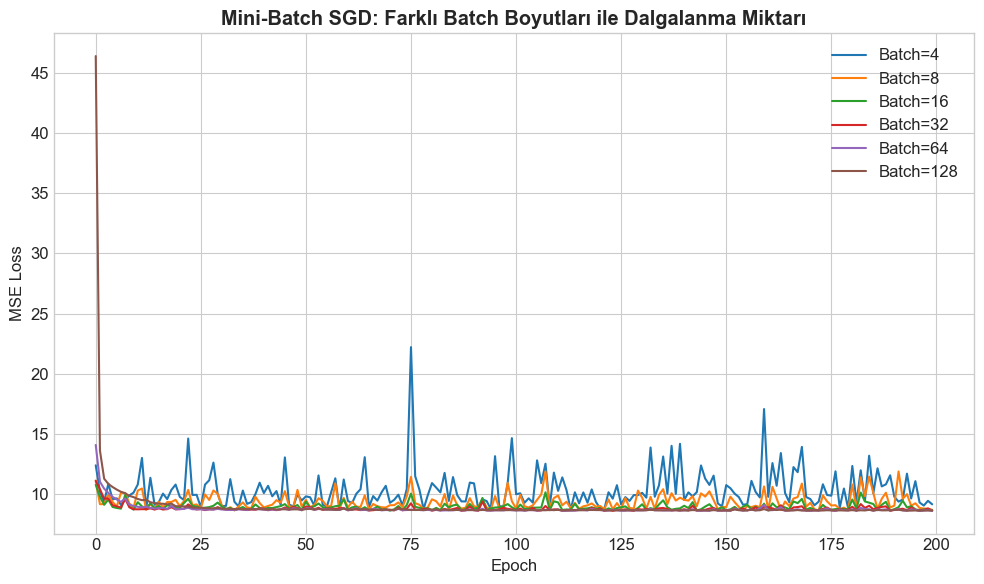


YORUM: Küçük batch boyutları (4, 8) daha fazla dalgalanma gösteriyor - ama daha hızlı öğreniyor.
Büyük batch boyutları (64, 128) daha az dalgalanma gösteriyor - ama daha yavaş öğreniyor.
Ayrıca batch büyüdükçe ilk başta başladığı MSE loss daha yüksek oluyor - çünkü daha az güncelleme yapıyor. Bu yüzden mini-batch boyutu seçimi çok önemli.


In [33]:
print("\n ==== Egzersiz 3: Mini-Batch SGD Farklı Batch Boytularına Göre Dalgalanma Miktarı ====")

X = enerji[['X1', 'X2', 'X3', 'X4', 'X5', 'X7']].values
y = enerji['Y1'].values.reshape(-1, 1)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)  # standartlaştır
n, d = X_std.shape
X_ext = np.column_stack([np.ones(n), X_std])  # intercept sütunu

def mse_loss(beta, X, y):
    return np.mean((X @ beta - y) ** 2)

def gradyan_mse(beta, X, y):
    return (2 / len(y)) * X.T @ (X @ beta - y)

rng = np.random.default_rng(42)
beta_baslangic = rng.normal(0, 0.1, (d + 1, 1)) # Başlangıç ağırlıkları (intercept dahil)
alpha = 0.1 # Ögrenme oranı (learning rate)
n_epoch = 200 # Kaç kez tüm veri üzerinden geçilecek (batch GD için) veya kaç kez mini-batch SGD yapılacak

# ===== MINI-BATCH SGD: Farklı batch boyutları ile =====
batch_boyutlari = [4, 8, 16, 32, 64, 128]
loss_sgd_dict = {}
for batch_boyutu in batch_boyutlari:
    beta_sgd = beta_baslangic.copy()
    loss_sgd = []
    rng2 = np.random.default_rng(0)
    for epoch in range(n_epoch):
        karisik_index = rng2.permutation(n)
        for i in range(0, n, batch_boyutu):
            alt_ornek_idx = karisik_index[i:i + batch_boyutu]
            X_batch, y_batch = X_ext[alt_ornek_idx], y[alt_ornek_idx]
            grad = gradyan_mse(beta_sgd, X_batch, y_batch)
            beta_sgd = beta_sgd - alpha * grad
        loss_sgd.append(mse_loss(beta_sgd, X_ext, y))  # TUM veri uzerinde loss'u olc (karsilastirma icin)
    loss_sgd_dict[batch_boyutu] = loss_sgd
    print(f"Batch boyutu {batch_boyutu} - ilk loss: {loss_sgd[0]:.3f}, son loss: {loss_sgd[-1]:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
for batch_boyutu, loss_sgd in loss_sgd_dict.items():
    ax.plot(loss_sgd, label=f'Batch={batch_boyutu}')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Mini-Batch SGD: Farklı Batch Boyutları ile Dalgalanma Miktarı', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Küçük batch boyutları (4, 8) daha fazla dalgalanma gösteriyor - ama daha hızlı öğreniyor.")
print("Büyük batch boyutları (64, 128) daha az dalgalanma gösteriyor - ama daha yavaş öğreniyor.")
print("Ayrıca batch büyüdükçe ilk başta başladığı MSE loss daha yüksek oluyor - çünkü daha az güncelleme yapıyor. Bu yüzden mini-batch boyutu seçimi çok önemli.")

---

### **E4.** 
Python 5'teki Adam'ı, `beta2` değerini `0.999`'dan `0.9`'a düşürerek ve `0.9999`'a artırarak tekrarla
(bu, ikinci momentin daha "unutkan" olmasını sağlar). Yakınsama hızı/kararlılığı nasıl
etkileniyor?


 ==== Egzersiz 4: Adam'daki Beta2 Değerini Değiştirerek Öğrenme Hızını ve Dalgalanmayı Gözlemleme ====
Beta2=0.9 - Son nokta: [1.0008 0.9952], f=0.0040312499
Beta2=0.999 - Son nokta: [1. 1.], f=0.0000000000
Beta2=0.9999 - Son nokta: [1. 1.], f=0.0000000000


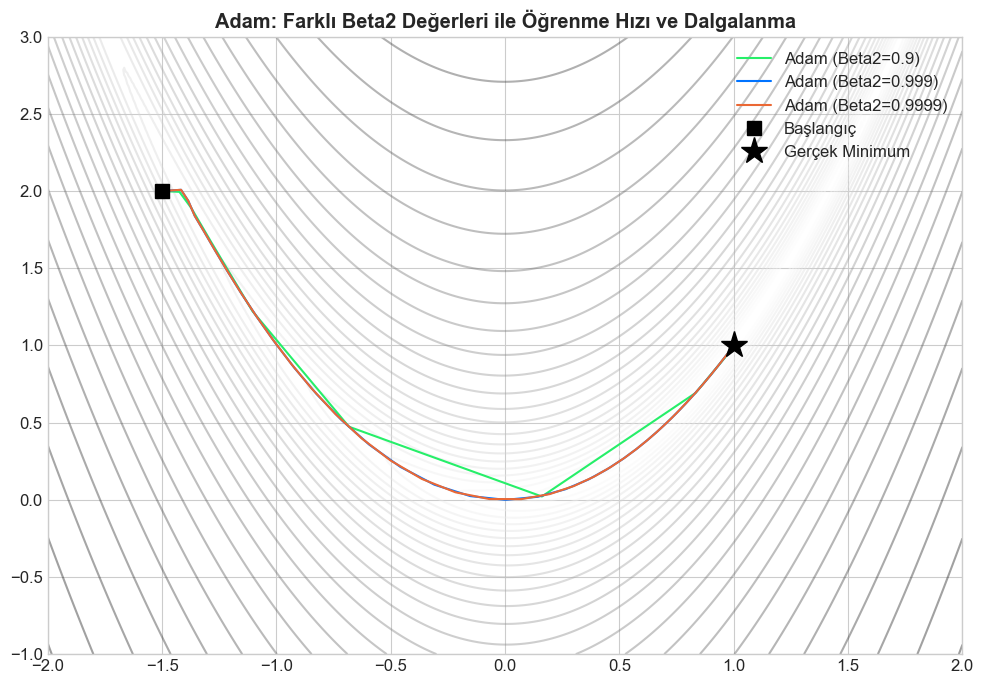


YORUM: Beta2=0.9 ile daha hızlı ama daha fazla dalgalanma var. Beta2=0.999 ile daha yavaş ama daha stabil. Beta2=0.9999 ile daha sakin ama çok yavaş. Bu yüzden Beta2 değeri, Adam'ın öğrenme hızını ve dalgalanmasını kontrol etmek için önemli bir hiperparametredir.


In [38]:
print("\n ==== Egzersiz 4: Adam'daki Beta2 Değerini Değiştirerek Öğrenme Hızını ve Dalgalanmayı Gözlemleme ====")

def adam_gd(baslangic, alpha, beta1, beta2, n_adim, eps=1e-8):
    yol = [baslangic.copy()]
    nokta = baslangic.copy()
    m = np.zeros(2); v = np.zeros(2)  # Bolum 5'teki birinci ve ikinci moment
    for t in range(1, n_adim + 1):
        grad = gradyan_rosenbrock(*nokta)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**t)   # "bias correction" - baslangicta m,v sifira yakin oldugu icin duzeltme
        v_hat = v / (1 - beta2**t)
        nokta = nokta - alpha * m_hat / (np.sqrt(v_hat) + eps)
        yol.append(nokta.copy())
    return np.array(yol)

yol_adam_beta2_1 = adam_gd(baslangic_r, alpha=0.05, beta1=0.9, beta2=0.9, n_adim=n_adim_r)
yol_adam_beta2_2 = adam_gd(baslangic_r, alpha=0.05, beta1=0.9, beta2=0.999, n_adim=n_adim_r)
yol_adam_beta2_3 = adam_gd(baslangic_r, alpha=0.05, beta1=0.9, beta2=0.9999, n_adim=n_adim_r)

print(f"Beta2=0.9 - Son nokta: {np.round(yol_adam_beta2_1[-1], 4)}, f={rosenbrock(*yol_adam_beta2_1[-1]):.10f}")
print(f"Beta2=0.999 - Son nokta: {np.round(yol_adam_beta2_2[-1], 4)}, f={rosenbrock(*yol_adam_beta2_2[-1]):.10f}")
print(f"Beta2=0.9999 - Son nokta: {np.round(yol_adam_beta2_3[-1], 4)}, f={rosenbrock(*yol_adam_beta2_3[-1]):.10f}")

fig, ax = plt.subplots(figsize=(10, 7))
ax.contour(X_r, Y_r, np.log(Z_r + 1), levels=30, cmap='Greys', alpha=0.4)
ax.plot(yol_adam_beta2_1[::20, 0], yol_adam_beta2_1[::20, 1], '-', color="#26ef69", linewidth=1.5, label='Adam (Beta2=0.9)')
ax.plot(yol_adam_beta2_2[::20, 0], yol_adam_beta2_2[::20, 1], '-', color="#0073ff", linewidth=1.5, label='Adam (Beta2=0.999)')
ax.plot(yol_adam_beta2_3[::20, 0], yol_adam_beta2_3[::20, 1], '-', color='#eb6834', linewidth=1.5, label='Adam (Beta2=0.9999)')
ax.plot(*baslangic_r, 's', color='black', markersize=10, label='Başlangıç')
ax.plot(1, 1, 'k*', markersize=20, label='Gerçek Minimum')
ax.set_title('Adam: Farklı Beta2 Değerleri ile Öğrenme Hızı ve Dalgalanma', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Beta2=0.9 ile daha hızlı ama daha fazla dalgalanma var. Beta2=0.999 ile daha yavaş ama daha stabil. Beta2=0.9999 ile daha sakin ama çok yavaş. Bu yüzden Beta2 değeri, Adam'ın öğrenme hızını ve dalgalanmasını kontrol etmek için önemli bir hiperparametredir.")

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [3Blue1Brown — Essence of Calculus (Gradient Descent)](https://www.3blue1brown.com/topics/calculus) | — | Genel sezgi |
| [Sebastian Ruder — An Overview of Gradient Descent Optimization Algorithms](https://ruder.io/optimizing-gradient-descent/) | — | SGD/Momentum/Adam'ın en kapsamlı yazılı karşılaştırması |
| [distill.pub — Why Momentum Really Works](https://distill.pub/2017/momentum/) | — | Momentum'un görsel/interaktif anlatımı |
| [Kingma & Ba (2015) — Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980) | — | Adam'ın orijinal makalesi |
| [Mathematics for Machine Learning](https://mml-book.github.io) | Ch. 7 | Optimizasyon, ML bağlamında |
| [Energy Efficiency Dataset (UCI)](https://archive.ics.uci.edu/dataset/242/energy+efficiency) | Veri | ENB2012_data.xlsx kaynağı |